In [1]:
import pandas as pd
from src.detector import detect
from src.utils.metrics import bone_wise_metrics
from src.detector.checkers import AbsoluteLimitChecker, GravityAlignmentChecker, AngularVelocityChecker, LinearAccelerationChecker

In [2]:
df = pd.read_parquet("data/validation.parquet")

In [3]:
broken_cols = df.filter(regex="Broken").columns.tolist()
broken_labels = df[broken_cols].notna()

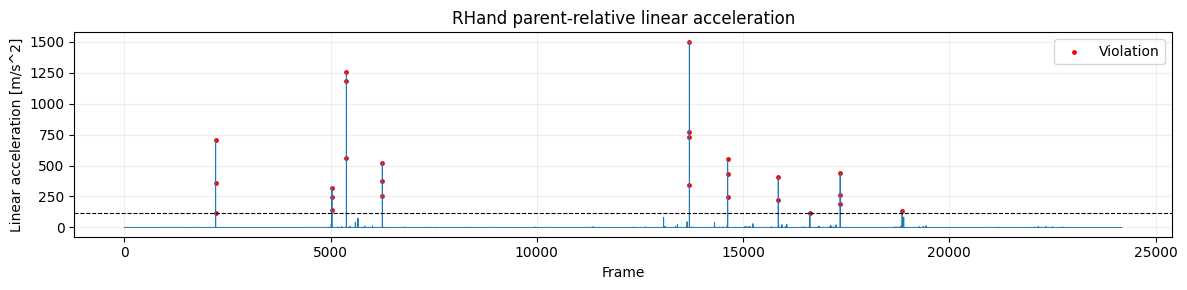

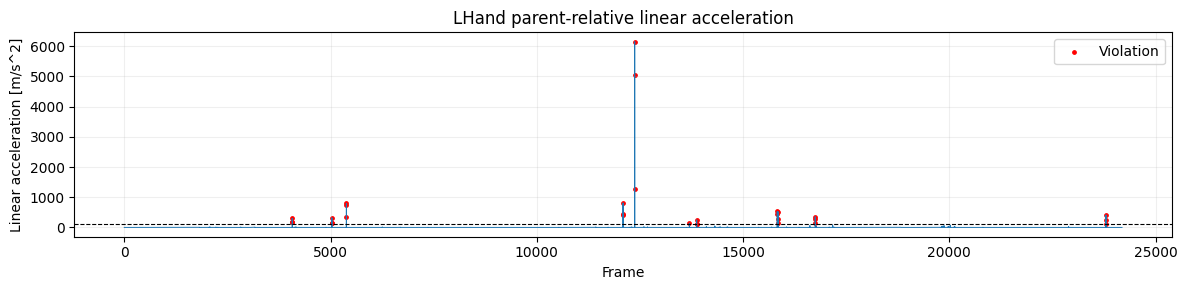

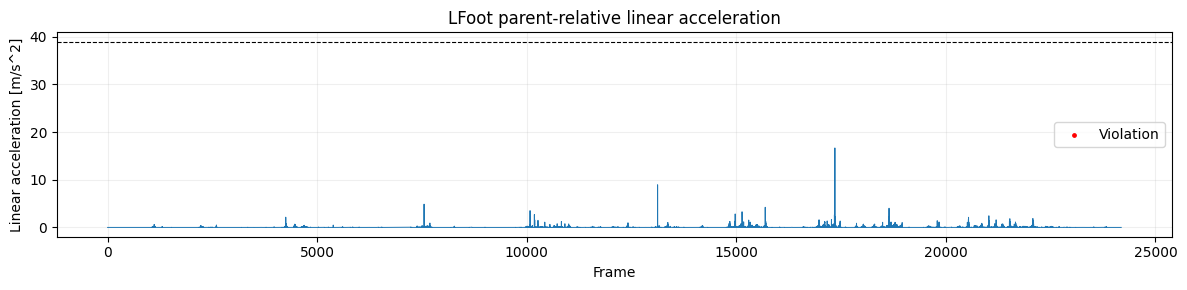

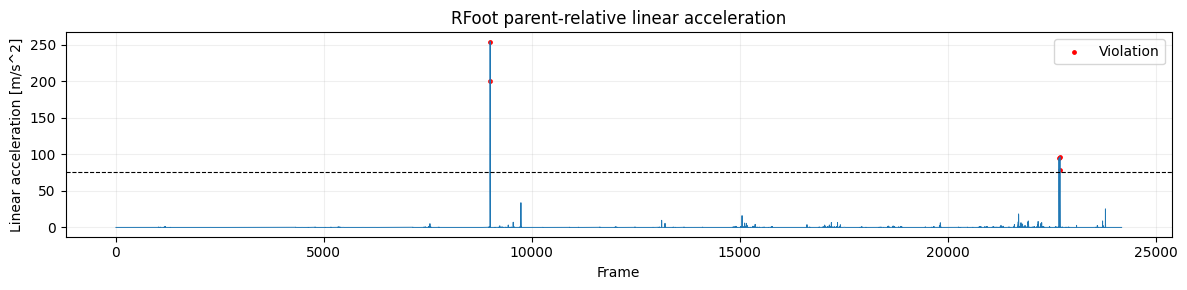

,BrokenHip,BrokenAb,BrokenChest,BrokenNeck,BrokenLShoulder,BrokenRShoulder,BrokenLUArm,BrokenRUArm,BrokenLFArm,BrokenRFArm,...,BrokenRHand,BrokenLThigh,BrokenRThigh,BrokenLShin,BrokenRShin,BrokenLFoot,BrokenRFoot,BrokenHead,broken,checkers
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24181,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
24182,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
24183,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]
24184,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,[]


In [4]:
res = detect(
    df,
    [
        # AbsoluteLimitChecker(
        #     calibrate=True,
        #     plot=False,
        #     tpose_window=500,
        # ),
        # GravityAlignmentChecker(
        #     bones=["RHand", "LHand"],
        #     threshold_cos=0.7,
        #     calibration_window=500,
        #     temporal_filter=True,
        #     temporal_required=35,
        #     temporal_window=40
        # ),
        AngularVelocityChecker(
            threshold_rad_s=10.0,
            bones=["RHand", "LHand", "LFoot", "RFoot"],
            plot=False,
        ),
        LinearAccelerationChecker(
            bones=["RHand", "LHand", "LFoot", "RFoot"],
            plot=True,
        )
    ],
)
res

In [5]:
bone_wise_metrics(broken_labels, res, ['RHand', 'LHand', 'RFoot', 'LFoot'])

,bone,precision,recall,f1,support
0,RHand,0.568323,0.037060,0.069582,4938
1,LHand,0.695286,0.057529,0.106265,7179
2,RFoot,0.396825,0.026838,0.050277,1863
3,LFoot,0.340909,0.018564,0.035211,808
